# RetailIQ — Customer Segmentation & Purchase Behaviour Analytics

**Goal:** Segment customers using their purchasing behaviour so that a retailer can identify high-value, regular, occasional and low-engagement customer groups.

### What this notebook covers
1. Load the two-year Online Retail II dataset
2. Audit data quality
3. Clean cancellations, invalid transactions and missing customer IDs
4. Perform exploratory analysis
5. Engineer **RFM** features: Recency, Frequency and Monetary value
6. Prepare features for clustering
7. Use the **Elbow Method** and **Silhouette Score** to inspect cluster quality
8. Build a **K-Means** customer segmentation model
9. Visualise clusters using **PCA**
10. Profile and interpret the customer segments
11. Export customer-level and cluster-level results

The project deliberately uses straightforward, explainable data-science methods rather than unnecessarily complex models.

## 1. Setup

Run this cell first in Google Colab. `openpyxl` is required because the source dataset is an Excel workbook.

In [1]:
!pip -q install openpyxl

In [2]:
import os
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42

## 2. Upload the dataset

When prompted, upload **`online_retail_II.xlsx`**.

The notebook also works outside Colab if the file is already present in the current working directory.

In [4]:
DATA_FILE = "online_retail_II.xlsx"

try:
    from google.colab import files
    if not os.path.exists(DATA_FILE):
        print(f"Upload {DATA_FILE}")
        uploaded = files.upload()
        if DATA_FILE not in uploaded:
            # If the user uploaded the same workbook with a slightly different name,
            # use the first uploaded .xlsx file.
            xlsx_files = [name for name in uploaded if name.lower().endswith(".xlsx")]
            if not xlsx_files:
                raise FileNotFoundError("No .xlsx file was uploaded.")
            DATA_FILE = xlsx_files[0]
except ImportError:
    if not os.path.exists(DATA_FILE):
        raise FileNotFoundError(
            f"Place '{DATA_FILE}' in the current working directory before running this notebook."
        )

print("Using dataset:", DATA_FILE)

Upload online_retail_II.xlsx


Saving online_retail_II.xlsx to online_retail_II.xlsx
Using dataset: online_retail_II.xlsx


## 3. Load both years of transactions

The workbook contains two sheets:
- `Year 2009-2010`
- `Year 2010-2011`

We combine them into one transaction table before analysis.

In [5]:
excel_file = pd.ExcelFile(DATA_FILE)
print("Sheets found:", excel_file.sheet_names)

required_sheets = ["Year 2009-2010", "Year 2010-2011"]
missing_sheets = [s for s in required_sheets if s not in excel_file.sheet_names]
if missing_sheets:
    raise ValueError(f"Expected sheets not found: {missing_sheets}")

frames = []
for sheet in required_sheets:
    temp = pd.read_excel(DATA_FILE, sheet_name=sheet)
    temp["SourceYear"] = sheet
    frames.append(temp)

df_raw = pd.concat(frames, ignore_index=True)

print("Combined shape:", df_raw.shape)
df_raw.head()

Sheets found: ['Year 2009-2010', 'Year 2010-2011']
Combined shape: (1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Year 2009-2010


## 4. Initial data audit

Before cleaning anything, inspect the dataset. This is important because negative quantities, cancellations and missing customer IDs have different meanings.

In [6]:
print("Rows:", f"{len(df_raw):,}")
print("Columns:", df_raw.shape[1])
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = pd.DataFrame({
    "Missing Count": df_raw.isna().sum(),
    "Missing %": df_raw.isna().mean() * 100
}).sort_values("Missing Count", ascending=False)
display(missing)

print("Duplicate rows:", f"{df_raw.duplicated().sum():,}")

Rows: 1,067,371
Columns: 9

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SourceYear']

Data types:


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object
SourceYear,object



Missing values:


,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00
SourceYear,0,0.00


Duplicate rows: 12,133


In [7]:
# Basic range and cardinality checks
print("Date range:", df_raw["InvoiceDate"].min(), "to", df_raw["InvoiceDate"].max())
print("Unique invoices:", f"{df_raw['Invoice'].nunique():,}")
print("Unique customers:", f"{df_raw['Customer ID'].nunique(dropna=True):,}")
print("Unique stock codes:", f"{df_raw['StockCode'].nunique():,}")
print("Countries:", f"{df_raw['Country'].nunique():,}")

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique invoices: 53,628
Unique customers: 5,942
Unique stock codes: 5,305
Countries: 43


### Investigate cancellations and invalid transaction values

Invoices beginning with `C` represent cancellations. We also inspect non-positive quantity and price values before defining the customer-purchase population.

In [8]:
audit = df_raw.copy()
audit["Invoice"] = audit["Invoice"].astype(str)

quality_checks = pd.Series({
    "Cancelled invoice lines": audit["Invoice"].str.startswith("C", na=False).sum(),
    "Quantity <= 0": (audit["Quantity"] <= 0).sum(),
    "Price <= 0": (audit["Price"] <= 0).sum(),
    "Missing Customer ID": audit["Customer ID"].isna().sum(),
    "Missing Description": audit["Description"].isna().sum(),
    "Duplicate rows": audit.duplicated().sum(),
})

display(quality_checks.to_frame("Rows"))

,Rows
Cancelled invoice lines,19494
Quantity <= 0,22950
Price <= 0,6207
Missing Customer ID,243007
Missing Description,4382
Duplicate rows,12133


## 5. Data cleaning

For **customer segmentation**, we need successful purchase transactions that can be linked to a known customer.

We therefore:
- remove rows with missing `Customer ID`;
- remove cancelled invoices;
- keep only positive quantities;
- keep only positive prices;
- remove exact duplicate rows;
- create transaction-level revenue as `Quantity × Price`.

We keep the raw dataset unchanged in `df_raw` for auditability.

In [9]:
df = df_raw.copy()

# Standardise invoice type for cancellation checks
df["Invoice"] = df["Invoice"].astype(str)

# 1. Customer-level analysis requires an identifiable customer
df = df.dropna(subset=["Customer ID"]).copy()

# 2. Exclude cancellations
df = df[~df["Invoice"].str.startswith("C", na=False)].copy()

# 3. Keep normal positive-value purchases
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()

# 4. Remove exact duplicates
df = df.drop_duplicates().copy()

# 5. Clean customer ID representation
df["Customer ID"] = df["Customer ID"].astype(int).astype(str)

# 6. Ensure datetime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# 7. Transaction revenue
df["Revenue"] = df["Quantity"] * df["Price"]

print("Raw rows:", f"{len(df_raw):,}")
print("Clean purchase rows:", f"{len(df):,}")
print("Rows retained:", f"{len(df) / len(df_raw) * 100:.1f}%")
print("Customers retained:", f"{df['Customer ID'].nunique():,}")
print("Invoices retained:", f"{df['Invoice'].nunique():,}")

Raw rows: 1,067,371
Clean purchase rows: 793,609
Rows retained: 74.4%
Customers retained: 5,878
Invoices retained: 36,969


## 6. Exploratory Data Analysis

The purpose of this section is not to create dozens of charts. We focus on a few questions that help us understand customer purchasing behaviour before clustering.

In [10]:
summary = pd.Series({
    "Transactions": len(df),
    "Customers": df["Customer ID"].nunique(),
    "Invoices": df["Invoice"].nunique(),
    "Products": df["StockCode"].nunique(),
    "Countries": df["Country"].nunique(),
    "Total Revenue": df["Revenue"].sum(),
    "Average Order Value": df.groupby("Invoice")["Revenue"].sum().mean(),
})

display(summary.to_frame("Value"))

,Value
Transactions,"793,609.00"
Customers,"5,878.00"
Invoices,"36,969.00"
Products,"4,631.00"
Countries,41.00
Total Revenue,"17,685,460.64"
Average Order Value,478.39


### 6.1 Revenue by country

,Revenue,Customers,Invoices
Country,,,
United Kingdom,"14,666,669.08",5350,33541
EIRE,"621,304.32",5,567
Netherlands,"554,230.69",22,228
Germany,"430,703.79",107,789
France,"355,059.38",95,614
Australia,"169,900.61",15,95
Spain,"109,127.21",41,154
Switzerland,"100,365.34",22,90
Sweden,"91,515.82",19,104


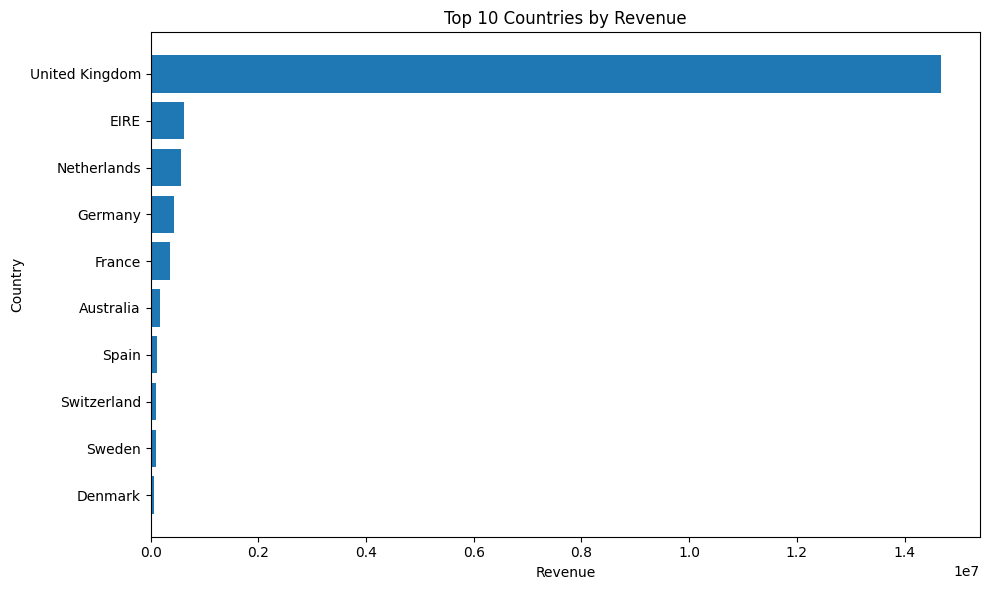

In [11]:
country_summary = (
    df.groupby("Country")
      .agg(Revenue=("Revenue", "sum"), Customers=("Customer ID", "nunique"), Invoices=("Invoice", "nunique"))
      .sort_values("Revenue", ascending=False)
)

display(country_summary.head(10))

top_countries = country_summary.head(10).sort_values("Revenue")
plt.figure(figsize=(10, 6))
plt.barh(top_countries.index, top_countries["Revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### 6.2 Monthly revenue trend

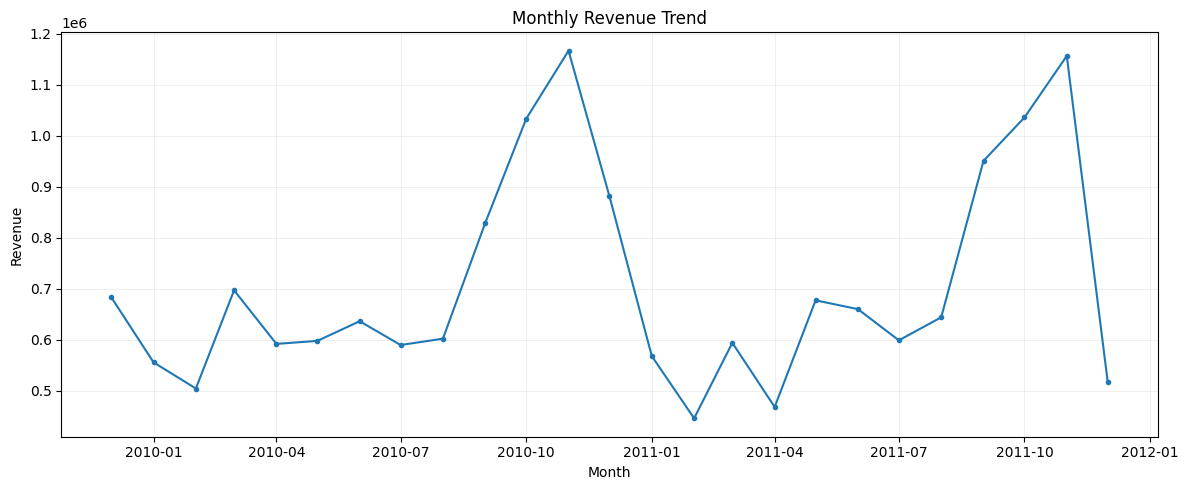

In [12]:
monthly_revenue = (
    df.set_index("InvoiceDate")
      .resample("MS")["Revenue"]
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", markersize=3)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 6.3 Top products by revenue

In [13]:
product_summary = (
    df.groupby(["StockCode", "Description"], dropna=False)
      .agg(Revenue=("Revenue", "sum"), Quantity=("Quantity", "sum"))
      .sort_values("Revenue", ascending=False)
      .head(10)
      .reset_index()
)

display(product_summary)

,StockCode,Description,Revenue,Quantity
0,22423,REGENCY CAKESTAND 3 TIER,"285,992.35",24858
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"251,731.26",93520
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995
3,M,Manual,"151,951.92",9501
4,85099B,JUMBO BAG RED RETROSPOT,"136,684.79",75597
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"126,704.06",79694
6,POST,POSTAGE,"126,563.04",5333
7,47566,PARTY BUNTING,"103,802.53",23591
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"79,455.68",29430


## 7. RFM feature engineering

We now convert transaction-level data into one row per customer.

### Recency
Number of days since the customer's most recent purchase. **Lower is better/more recent.**

### Frequency
Number of distinct invoices/orders placed by the customer. **Higher means more repeat purchasing.**

### Monetary
Total revenue generated by the customer. **Higher indicates greater historical customer value.**

In [14]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Analysis date:", analysis_date.date())

rfm = (
    df.groupby("Customer ID")
      .agg(
          Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
          Frequency=("Invoice", "nunique"),
          Monetary=("Revenue", "sum"),
          FirstPurchase=("InvoiceDate", "min"),
          LastPurchase=("InvoiceDate", "max"),
      )
      .reset_index()
)

rfm["CustomerTenureDays"] = (analysis_date - rfm["FirstPurchase"]).dt.days

print("Customer-level RFM shape:", rfm.shape)
display(rfm.head())

Analysis date: 2011-12-10
Customer-level RFM shape: (5878, 7)


,Customer ID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,CustomerTenureDays
0,12346,326,12,"77,556.46",2009-12-14 08:34:00,2011-01-18 10:01:00,726
1,12347,2,8,"5,633.32",2010-10-31 14:20:00,2011-12-07 15:52:00,404
2,12348,75,5,"2,019.40",2010-09-27 14:59:00,2011-09-25 13:13:00,438
3,12349,19,4,"4,428.69",2010-04-29 13:20:00,2011-11-21 09:51:00,589
4,12350,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,310


In [15]:
print("RFM descriptive statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)

RFM descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Recency,"5,878.00",201.33,209.34,1.00,26.00,96.00,380.00,739.00
Frequency,"5,878.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,"5,878.00","3,008.75","14,731.92",2.95,345.12,887.39,"2,298.01","608,821.65"


### 7.1 Inspect RFM distributions

RFM variables are usually highly right-skewed, especially Frequency and Monetary value. K-Means uses Euclidean distance, so extreme values can disproportionately influence clusters.

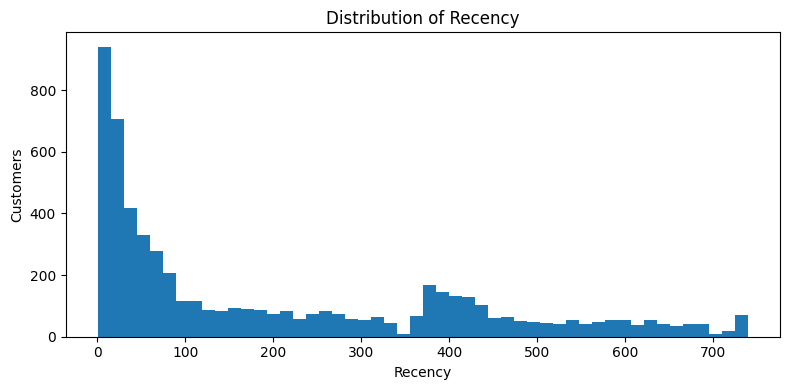

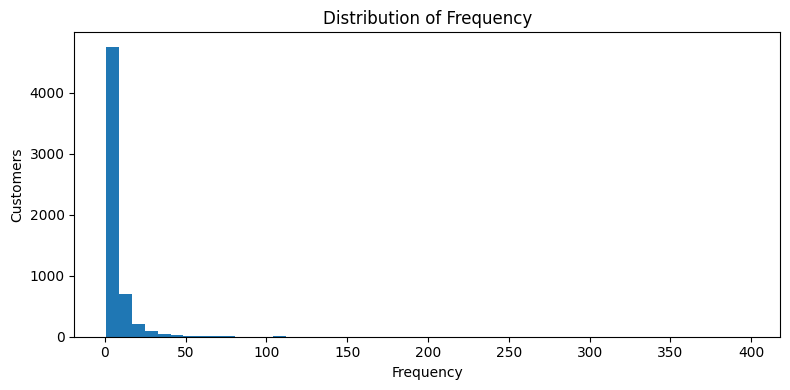

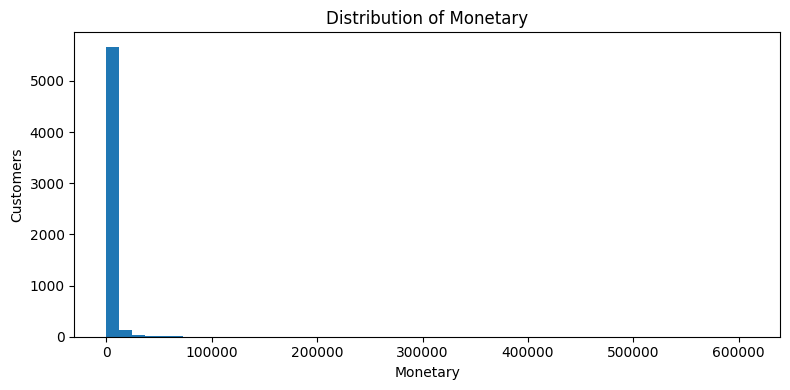

In [16]:
for column in ["Recency", "Frequency", "Monetary"]:
    plt.figure(figsize=(8, 4))
    plt.hist(rfm[column], bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Customers")
    plt.tight_layout()
    plt.show()

## 8. Prepare RFM features for K-Means

We keep the original RFM values for interpretation, but prepare a transformed copy for modelling.

Steps:
1. Clip each feature at the 1st and 99th percentiles to reduce the effect of extreme outliers.
2. Apply `log1p` to reduce right-skew.
3. Standardise all three features so they contribute on comparable scales.

In [17]:
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Winsorise extreme values without deleting customers
for col in rfm_model.columns:
    lower = rfm_model[col].quantile(0.01)
    upper = rfm_model[col].quantile(0.99)
    rfm_model[col] = rfm_model[col].clip(lower=lower, upper=upper)

# Reduce skew
rfm_log = np.log1p(rfm_model)

# Standardise
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"],
    index=rfm.index,
)

display(rfm_scaled_df.head())

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,0.86,1.29,2.58
1,-2.15,0.83,1.34
2,-0.08,0.31,0.58
3,-0.94,0.08,1.16
4,0.82,-1.08,-0.75


## 9. Inspect the number of clusters

There is no single perfect value of `K`. We inspect:
- **Elbow Method:** looks for diminishing improvement in within-cluster variance;
- **Silhouette Score:** measures how well separated the clusters are.

For this portfolio project, we will use **4 clusters** because it produces a simple and interpretable customer segmentation. The table below lets you inspect how that choice compares with alternatives.

In [18]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

k_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores,
})

display(k_evaluation)

,K,Inertia,Silhouette Score
0,2,"8,397.28",0.44
1,3,"6,151.66",0.35
2,4,"4,706.57",0.37
3,5,"3,930.95",0.34
4,6,"3,371.52",0.34
5,7,"3,014.76",0.31
6,8,"2,726.89",0.30


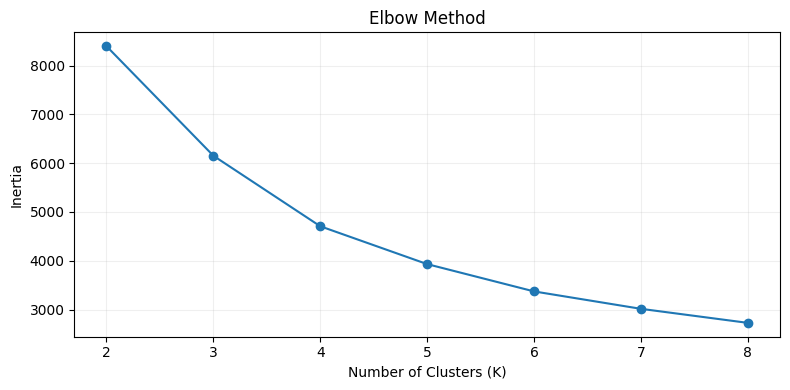

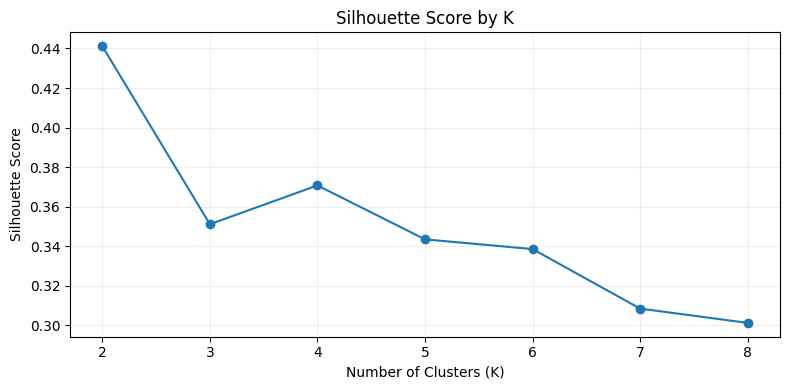

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(k_evaluation["K"], k_evaluation["Inertia"], marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_evaluation["K"])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(k_evaluation["K"], k_evaluation["Silhouette Score"], marker="o")
plt.title("Silhouette Score by K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_evaluation["K"])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Train the final K-Means model

We use **4 clusters** for a clear business segmentation. Cluster numbers themselves have no inherent meaning; we interpret them only after comparing the actual RFM profiles.

In [20]:
SELECTED_K = 4

kmeans = KMeans(
    n_clusters=SELECTED_K,
    random_state=RANDOM_STATE,
    n_init=20,
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Final silhouette score:", round(silhouette_score(rfm_scaled, rfm["Cluster"]), 4))
print("\nCustomers per cluster:")
display(rfm["Cluster"].value_counts().sort_index().to_frame("Customers"))

Final silhouette score: 0.3707

Customers per cluster:


,Customers
Cluster,
0,1222
1,1461
2,1960
3,1235


## 11. Cluster profiling

Now we move back to the **original, unscaled RFM values**. This is the important interpretation step.

In [21]:
cluster_summary = (
    rfm.groupby("Cluster")
       .agg(
           Customers=("Customer ID", "count"),
           AvgRecency=("Recency", "mean"),
           MedianRecency=("Recency", "median"),
           AvgFrequency=("Frequency", "mean"),
           MedianFrequency=("Frequency", "median"),
           AvgMonetary=("Monetary", "mean"),
           MedianMonetary=("Monetary", "median"),
           TotalRevenue=("Monetary", "sum"),
       )
       .reset_index()
)

cluster_summary["CustomerShare_%"] = (
    cluster_summary["Customers"] / cluster_summary["Customers"].sum() * 100
)
cluster_summary["RevenueShare_%"] = (
    cluster_summary["TotalRevenue"] / cluster_summary["TotalRevenue"].sum() * 100
)

cluster_summary = cluster_summary.sort_values("Cluster").reset_index(drop=True)
display(cluster_summary)

,Cluster,Customers,AvgRecency,MedianRecency,AvgFrequency,MedianFrequency,AvgMonetary,MedianMonetary,TotalRevenue,CustomerShare_%,RevenueShare_%
0,0,1222,27.83,17.00,19.03,13.00,"10,760.88","5,038.85","13,149,797.41",20.79,74.35
1,1,1461,230.11,186.00,5.02,4.00,"1,972.48","1,488.59","2,881,790.80",24.86,16.29
2,2,1960,396.70,404.50,1.38,1.00,320.54,278.14,"628,263.54",33.34,3.55
3,3,1235,28.91,24.00,2.98,3.00,830.45,724.97,"1,025,608.89",21.01,5.80


### Create descriptive business labels

We assign labels **after** clustering. The labels are summaries of behaviour, not target classes used to train the model.

To make the naming reproducible, clusters are ranked using:
- lower Recency = better;
- higher Frequency = better;
- higher Monetary value = better.

The highest-scoring cluster is labelled `High-Value Loyal`; the lowest is labelled `Low-Engagement`, with two intermediate groups.

In [22]:
profile = cluster_summary[["Cluster", "AvgRecency", "AvgFrequency", "AvgMonetary"]].copy()

# Percentile ranks: higher score should mean more valuable/engaged
profile["RecencyScore"] = profile["AvgRecency"].rank(pct=True, ascending=False)
profile["FrequencyScore"] = profile["AvgFrequency"].rank(pct=True, ascending=True)
profile["MonetaryScore"] = profile["AvgMonetary"].rank(pct=True, ascending=True)
profile["OverallScore"] = profile[["RecencyScore", "FrequencyScore", "MonetaryScore"]].mean(axis=1)

ordered_clusters = profile.sort_values("OverallScore", ascending=False)["Cluster"].tolist()

segment_names = [
    "High-Value Loyal",
    "Regular Customers",
    "Occasional / Developing",
    "Low-Engagement / At-Risk",
]

cluster_to_segment = {
    cluster: segment_names[i]
    for i, cluster in enumerate(ordered_clusters)
}

rfm["Segment"] = rfm["Cluster"].map(cluster_to_segment)
cluster_summary["Segment"] = cluster_summary["Cluster"].map(cluster_to_segment)

cluster_summary = cluster_summary[
    [
        "Cluster", "Segment", "Customers", "CustomerShare_%",
        "AvgRecency", "AvgFrequency", "AvgMonetary",
        "TotalRevenue", "RevenueShare_%"
    ]
].sort_values("AvgMonetary", ascending=False)

display(cluster_summary)

,Cluster,Segment,Customers,CustomerShare_%,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,RevenueShare_%
0,0,High-Value Loyal,1222,20.79,27.83,19.03,"10,760.88","13,149,797.41",74.35
1,1,Regular Customers,1461,24.86,230.11,5.02,"1,972.48","2,881,790.80",16.29
3,3,Occasional / Developing,1235,21.01,28.91,2.98,830.45,"1,025,608.89",5.80
2,2,Low-Engagement / At-Risk,1960,33.34,396.70,1.38,320.54,"628,263.54",3.55


## 12. Visualise the cluster profiles

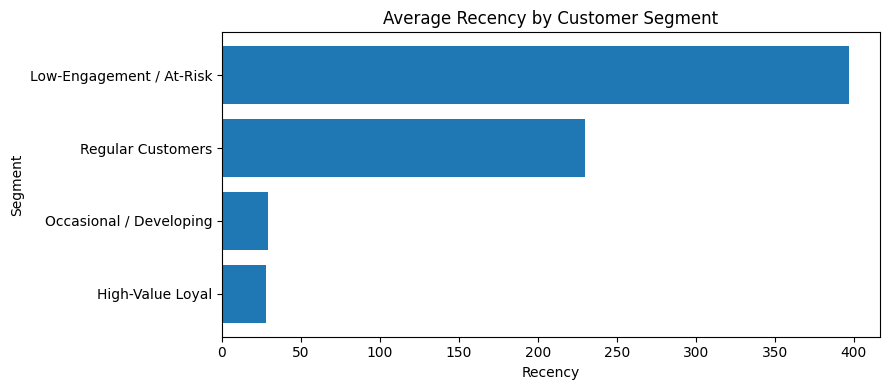

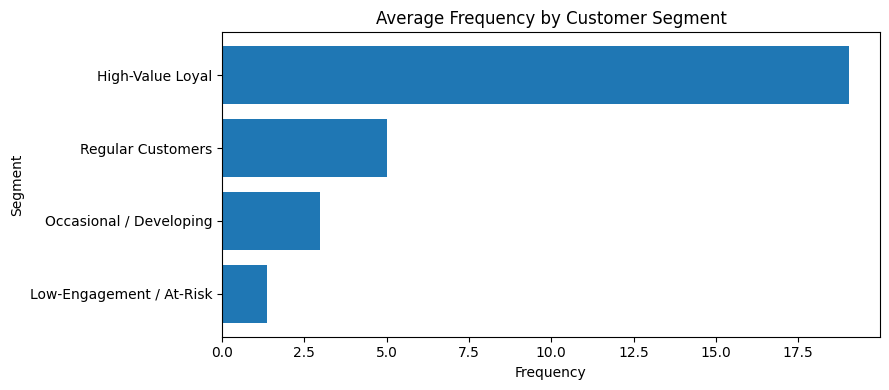

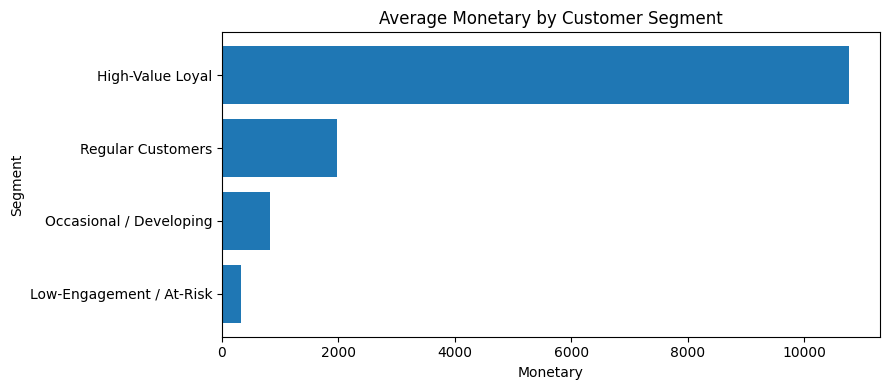

In [23]:
plot_summary = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
       .mean()
)

for metric in ["Recency", "Frequency", "Monetary"]:
    values = plot_summary[metric].sort_values()
    plt.figure(figsize=(9, 4))
    plt.barh(values.index, values.values)
    plt.title(f"Average {metric} by Customer Segment")
    plt.xlabel(metric)
    plt.ylabel("Segment")
    plt.tight_layout()
    plt.show()

## 13. PCA visualisation

K-Means was trained on three RFM dimensions. PCA projects those scaled features into two dimensions so we can visualise the clusters more easily.

PCA is **not** used to create the customer segments here; it is only a visualisation tool.

Variance explained by the two PCA components: 95.3%


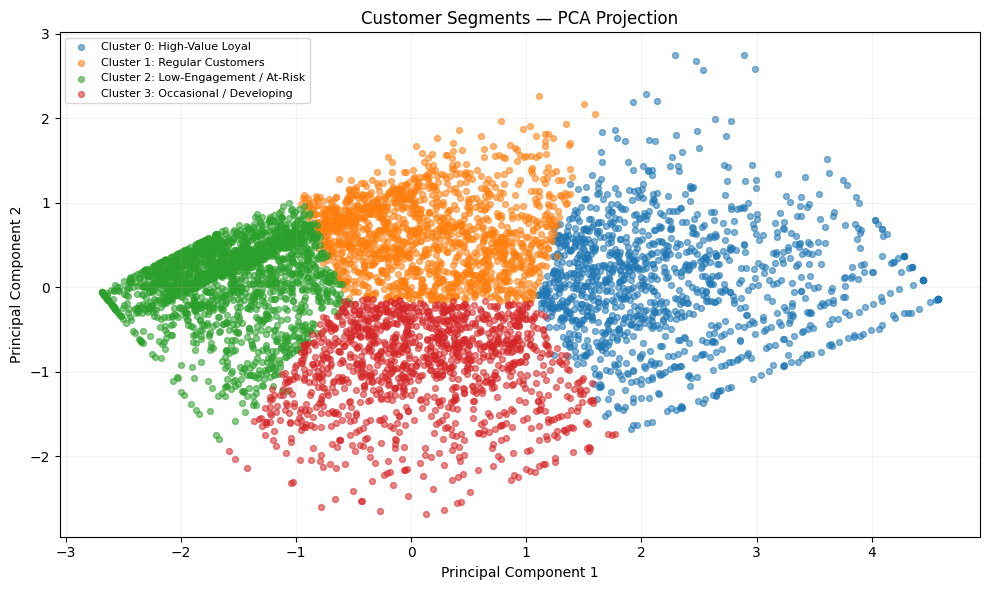

In [24]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = pca_components[:, 0]
rfm["PCA2"] = pca_components[:, 1]

print(
    "Variance explained by the two PCA components:",
    f"{pca.explained_variance_ratio_.sum() * 100:.1f}%"
)

plt.figure(figsize=(10, 6))
for cluster in sorted(rfm["Cluster"].unique()):
    subset = rfm[rfm["Cluster"] == cluster]
    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=18,
        alpha=0.55,
        label=f"Cluster {cluster}: {cluster_to_segment[cluster]}",
    )

plt.title("Customer Segments — PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(fontsize=8)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 14. Business interpretation

The following table converts the clusters into a simple action framework. These recommendations are examples based on the behavioural meaning of each segment, not outputs from the K-Means algorithm itself.

In [25]:
action_map = {
    "High-Value Loyal": "Prioritise retention, loyalty benefits, early access and premium cross-sell opportunities.",
    "Regular Customers": "Increase purchase frequency through personalised recommendations and targeted offers.",
    "Occasional / Developing": "Encourage a second or more frequent purchase with onboarding and relevant promotions.",
    "Low-Engagement / At-Risk": "Use low-cost re-engagement campaigns; avoid overspending on customers with persistently low value.",
}

business_summary = cluster_summary.copy()
business_summary["Suggested Action"] = business_summary["Segment"].map(action_map)

display(business_summary)

,Cluster,Segment,Customers,CustomerShare_%,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,RevenueShare_%,Suggested Action
0,0,High-Value Loyal,1222,20.79,27.83,19.03,"10,760.88","13,149,797.41",74.35,"Prioritise retention, loyalty benefits, early ..."
1,1,Regular Customers,1461,24.86,230.11,5.02,"1,972.48","2,881,790.80",16.29,Increase purchase frequency through personalis...
3,3,Occasional / Developing,1235,21.01,28.91,2.98,830.45,"1,025,608.89",5.80,Encourage a second or more frequent purchase w...
2,2,Low-Engagement / At-Risk,1960,33.34,396.70,1.38,320.54,"628,263.54",3.55,Use low-cost re-engagement campaigns; avoid ov...


## 15. Example customer-level output

This is what a marketing or CRM team could use operationally: each customer has behavioural features and an assigned segment.

In [26]:
customer_output = rfm[
    [
        "Customer ID", "Recency", "Frequency", "Monetary",
        "CustomerTenureDays", "Cluster", "Segment"
    ]
].sort_values(["Segment", "Monetary"], ascending=[True, False])

display(customer_output.head(20))

,Customer ID,Recency,Frequency,Monetary,CustomerTenureDays,Cluster,Segment
5692,18102,1,145,"608,821.65",739,0,High-Value Loyal
2277,14646,2,151,"528,602.52",737,0,High-Value Loyal
1789,14156,10,156,"313,759.82",739,0,High-Value Loyal
2538,14911,1,398,"295,832.39",739,0,High-Value Loyal
5050,17450,8,51,"246,813.09",438,0,High-Value Loyal
1331,13694,4,143,"196,482.81",735,0,High-Value Loyal
5109,17511,3,60,"175,603.55",738,0,High-Value Loyal
4061,16446,1,2,"168,472.50",206,0,High-Value Loyal
4295,16684,4,55,"147,142.77",732,0,High-Value Loyal
68,12415,24,28,"144,458.37",528,0,High-Value Loyal


## 16. Export results

The notebook creates:
- `customer_segments.csv` — one row per customer;
- `cluster_summary.csv` — cluster-level metrics;
- `k_evaluation.csv` — Elbow/Silhouette diagnostics;
- `RetailIQ_outputs.zip` — all three files bundled together.

In [27]:
OUTPUT_DIR = "retailiq_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

customer_output.to_csv(os.path.join(OUTPUT_DIR, "customer_segments.csv"), index=False)
business_summary.to_csv(os.path.join(OUTPUT_DIR, "cluster_summary.csv"), index=False)
k_evaluation.to_csv(os.path.join(OUTPUT_DIR, "k_evaluation.csv"), index=False)

zip_path = "RetailIQ_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for filename in os.listdir(OUTPUT_DIR):
        zf.write(os.path.join(OUTPUT_DIR, filename), arcname=filename)

print("Saved outputs:")
for filename in os.listdir(OUTPUT_DIR):
    print(" -", os.path.join(OUTPUT_DIR, filename))
print(" -", zip_path)

Saved outputs:
 - retailiq_outputs/customer_segments.csv
 - retailiq_outputs/k_evaluation.csv
 - retailiq_outputs/cluster_summary.csv
 - RetailIQ_outputs.zip


In [28]:
# Optional: download the output ZIP automatically when running in Google Colab.
try:
    from google.colab import files
    files.download("RetailIQ_outputs.zip")
except ImportError:
    print("Not running in Colab. The ZIP is available in the current directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final project summary

### Problem
A retailer has transaction-level purchase data but no predefined customer segments.

### Approach
- cleaned invalid/cancelled transactions;
- performed purchase-behaviour EDA;
- engineered **Recency, Frequency and Monetary (RFM)** features;
- treated skew/outliers and standardised the features;
- evaluated candidate values of `K` using **Elbow** and **Silhouette** diagnostics;
- used **K-Means** to identify four behavioural customer groups;
- used **PCA** to visualise the clusters;
- profiled each segment and translated it into simple customer-management actions.

### Core techniques demonstrated
`Pandas` • `EDA` • `Feature Engineering` • `RFM Analysis` • `StandardScaler` • `K-Means` • `Silhouette Score` • `PCA` • `Business Interpretation`

---

## Interview questions you should be able to answer

**Why did you remove missing Customer IDs?**  
Because the unit of analysis is the customer. Without an identifier, a transaction cannot be included in customer-level RFM features.

**Why did you remove cancelled and negative transactions?**  
The segmentation is designed around successful purchasing behaviour. Returns/cancellations are a different behavioural signal and could be modelled separately in an extension.

**Why RFM?**  
It converts raw transaction history into three intuitive customer-behaviour dimensions: how recently the customer purchased, how often they purchase and how much value they generate.

**Why standardise the features?**  
K-Means is distance-based. Monetary value can have a much larger numeric scale than Recency or Frequency, so unscaled data could allow one feature to dominate the distance calculation.

**Why log-transform the RFM variables?**  
Customer spending and purchase frequency are strongly skewed. The transformation reduces the influence of extreme values and makes distance-based clustering more stable.

**Why K-Means?**  
It is simple, computationally efficient, easy to interpret and appropriate when the goal is to group customers with similar continuous behavioural features.

**What does the Silhouette Score mean?**  
It measures how similar a customer is to its own cluster compared with neighbouring clusters. Higher values generally indicate more compact and better-separated clusters.

**Why PCA?**  
The clustering uses three features. PCA projects the scaled feature space into two dimensions so that the customer groups can be visualised; PCA is not used as the target or as a supervised model.

**What are the main limitations?**  
RFM uses historical transaction behaviour only. It does not incorporate demographics, product preferences, marketing exposure, profitability or causal response to interventions. K-Means also assumes distance-based cluster structure and requires the number of clusters to be specified.